# **02. Customer Segmentation using RFM Features**

## **Introduction**

In this notebook, we will apply an unsupervised machine learning approach to segment customers using RFM features. Building on the processed dataset prepared earlier, our goal is to group customers based on their recency, frequency, and monetary behavior. To make these segments more interpretable, we will assign customers to behavioral groups using RFM quartile scores, allowing us to identify meaningful categories such as loyal, high-value, or at-risk customers that can guide targeted marketing strategies.


### **GOAL**

Compute **Customer Lifetime Value (CLV)** refers to the total expected revenue a business can earn from a customer throughout their relationship. The longer a customer remains active and the more frequently they purchase, the higher their CLV.

A common way to estimate customer value over time is the **RFM model**, which considers:

- __Recency (R)__ : How recently the customer made a purchase.

- __Frequency (F)__ : How often the customer makes purchases.

- __Monetary (M)__ : How much the customer spends.

- __T (Tenure)__ : The duration between their first purchase and the end of the study period.


### **1. Requirements**

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown


In [3]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

    

In [4]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'processed')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)

0   processed_data.csv


In [5]:
display_md("**Loading Raw Dataset...**")
try:
    processed_df = pd.read_csv(files[0])
    
    # standardize the column names
    processed_df.columns = processed_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    customer_df = processed_df.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    #customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y', dayfirst=True)
    display_md(f"**Dataset Shape : {customer_df.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_df.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")

**Loading Raw Dataset...**

**Dataset Shape : (2214, 39)**

**Number of duplicate rows in dataset : 0**

In [6]:
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,1617,22,28
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,27,4,9
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,776,20,16
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,53,6,10
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,422,14,11


In [7]:
display_md(f"**Customer Information :**")
customer_df.info()

**Customer Information :**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2214 entries, 0 to 2213
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2214 non-null   int64  
 1   Year_Birth           2214 non-null   int64  
 2   Education            2214 non-null   object 
 3   Marital_Status       2214 non-null   object 
 4   Income               2214 non-null   float64
 5   Kidhome              2214 non-null   int64  
 6   Teenhome             2214 non-null   int64  
 7   Dt_Customer          2214 non-null   object 
 8   Recency              2214 non-null   int64  
 9   MntWines             2214 non-null   int64  
 10  MntFruits            2214 non-null   int64  
 11  MntMeatProducts      2214 non-null   int64  
 12  MntFishProducts      2214 non-null   int64  
 13  MntSweetProducts     2214 non-null   int64  
 14  MntGoldProds         2214 non-null   int64  
 15  NumDealsPurchases    2214 non-null   i

- `Education` & 'Marital_Status' are two categorical features.
- `Dt_Customer` only datetime feature.
- Other features are numbers.

In [8]:
## Column Formatting & Consistency
dtype_df = pd.DataFrame(
    index=customer_df.columns, columns=['dtype', 'nunique', 'unique']
)
dtype_df['dtype'] = customer_df.dtypes
dtype_df['nunique'] = customer_df.nunique()
dtype_df['unique'] = [customer_df[col].unique() for col in dtype_df.index]

display(dtype_df)

,dtype,nunique,unique
ID,int64,2214,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177..."
Year_Birth,int64,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 198..."
Education,object,4,"[Graduation, PhD, PostGraduation, UnderGraduat..."
Marital_Status,object,2,"[Single, Partner]"
Income,float64,1972,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, ..."
Kidhome,int64,3,"[0, 1, 2]"
Teenhome,int64,3,"[0, 1, 2]"
Dt_Customer,object,662,"[2012-09-04, 2014-03-08, 2013-08-21, 2014-02-1..."
Recency,int64,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 59, 82, 5..."
MntWines,int64,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 6, 1..."


## **2. Customer Segmentation**

- Customer segmentation is the practice of dividing a customer base into distinct groups that share similar characteristics—such as demographics, behaviors, or preferences—so businesses can tailor their marketing strategies more effectively to each segment.

- Instead of viewing all customers as one group, segment them into similar clusters, study their traits, and run relevant campaigns—beyond just income or location. 

To analyze customer personalities, three different clustering techniques were applied to the RFM features. Each method groups customers with similar characteristics and reveals different segmentation patterns.

**K-means Clustering with Elbow Method:**

We use K-means clustering to group customers by __RFM method__, and apply the Elbow Method to identify the optimal number of clusters—pinpointing where additional clusters no longer significantly improve the fit.

**K-means Clustering with Silhouette Analysis:**

K-means clustering was again employed, but the Silhouette Score was used to assess cluster quality. By measuring how well customers fit within their assigned clusters, this method helps determine the optimal number of clusters for effective segmentation.

**Gaussian Mixture Model with BIC:**

This method applies Gaussian Mixture Models (GMM), allowing for more flexible cluster shapes than K-means. The optimal number of clusters is selected using the Bayesian Information Criterion (BIC), which balances model fit and complexity.


#### __2.1.K-means Clustering with Elbow Method__

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## select features based on which customers will be segmented
rfm = customer_df[['Recency', 'Frequency', 'Monetary']]
print(rfm.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2214 entries, 0 to 2213
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    2214 non-null   int64
 1   Frequency  2214 non-null   int64
 2   Monetary   2214 non-null   int64
dtypes: int64(3)
memory usage: 52.0 KB
None


,no_cluster,wcss,explained_variance(%),pct_explained_variance
0,1,8.065504e+08,0.0000,NaN
1,2,1.834607e+08,0.7725,0.7725
2,3,8.230659e+07,0.8980,0.1255
3,4,4.768060e+07,0.9409,0.0429
4,5,3.212869e+07,0.9602,0.0193


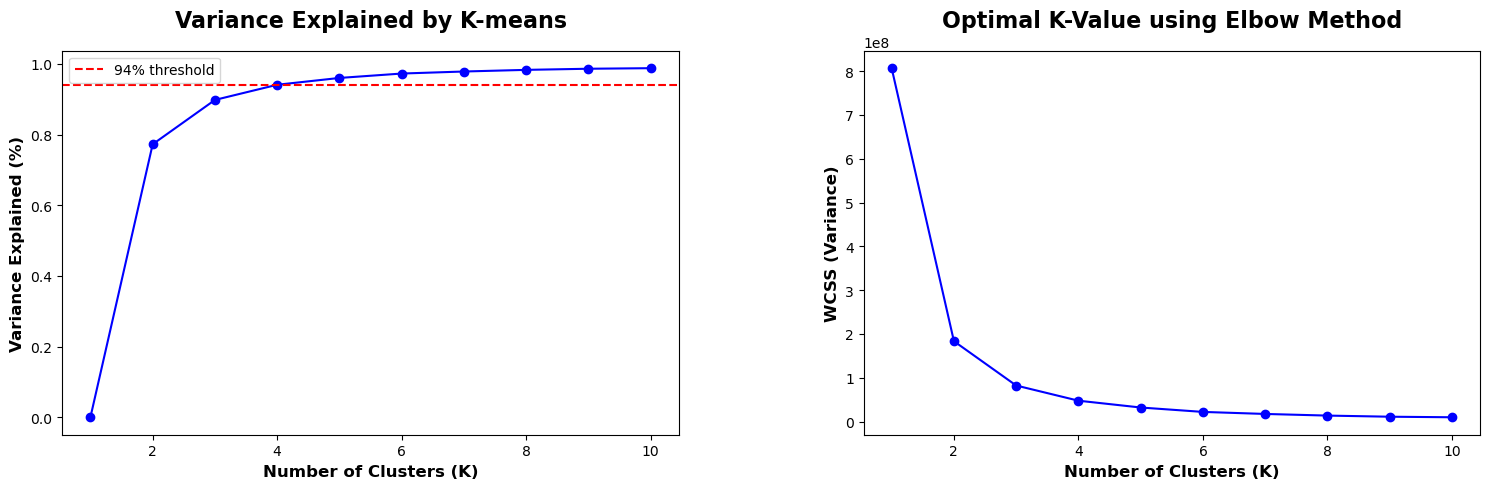

In [10]:
#  Total variance = sum of squared distances from mean
overall_mean = np.mean(np.array(rfm), axis=0)
total_variance = np.sum((np.array(rfm) - overall_mean)**2)

# KMeans Clustering with elbow method
wcss = []                           # Within-Cluster-Sum-of-Squares (WCSS)
explained_variance = []
n_cluster = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm)
    inertia = kmeans.inertia_
    wcss.append(inertia)
    bcss = total_variance - inertia      # between-cluster sum of squares
    explained_variance.append(bcss / total_variance)
    n_cluster.append(k)

# create dataframe
cluster_df = pd.DataFrame([], columns=['no_cluster', 'wcss', 'explained_variance(%)'])
cluster_df['no_cluster'] = n_cluster
cluster_df['wcss'] = wcss
cluster_df['explained_variance(%)'] = explained_variance
cluster_df['explained_variance(%)'] = cluster_df['explained_variance(%)'].map(lambda x: f'{x:.4f}').astype('float')
cluster_df = cluster_df.assign(pct_explained_variance=cluster_df['explained_variance(%)'].diff())
display(cluster_df.head())

# plot 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# plot no. of clusters with variance explained
ax[0].plot(range(1, 11), explained_variance, 'bo-')
ax[0].axhline(y=0.94, color='r', ls='--', label='94% threshold')
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax[0].set_title('Variance Explained by K-means', fontsize=16, fontweight='bold', y=1.04)
ax[0].legend()

# plot no. of clusters with elbow method
ax[1].plot(range(1, 11), wcss, 'bo-')
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('WCSS (Variance)', fontsize=12, fontweight='bold')
ax[1].set_title('Optimal K-Value using Elbow Method', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

In [11]:
# will choose the smallest k that explains at least 94% of the variance, which is k=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
y = kmeans.fit_predict(rfm)

# Add cluster labels to the DataFrame
cluster_df = pd.DataFrame(customer_df)
cluster_df.loc[:,'Cluster'] = y

# Interpret Clusters
cluster_summary = cluster_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg('mean')
cluster_summary['n_customers'] = cluster_df.groupby('Cluster').size()
cluster_summary['percentage_customers'] = ((cluster_summary['n_customers']/cluster_summary['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_summary)



,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,49.034972,6.017958,100.494329,1058,47.8%
1,51.509225,20.059041,1767.811808,271,12.2%
2,47.128806,16.264637,575.100703,427,19.3%
3,49.336245,19.805677,1122.580786,458,20.7%


#### **2.2. K-means Clustering with Silhouette Analysis:**

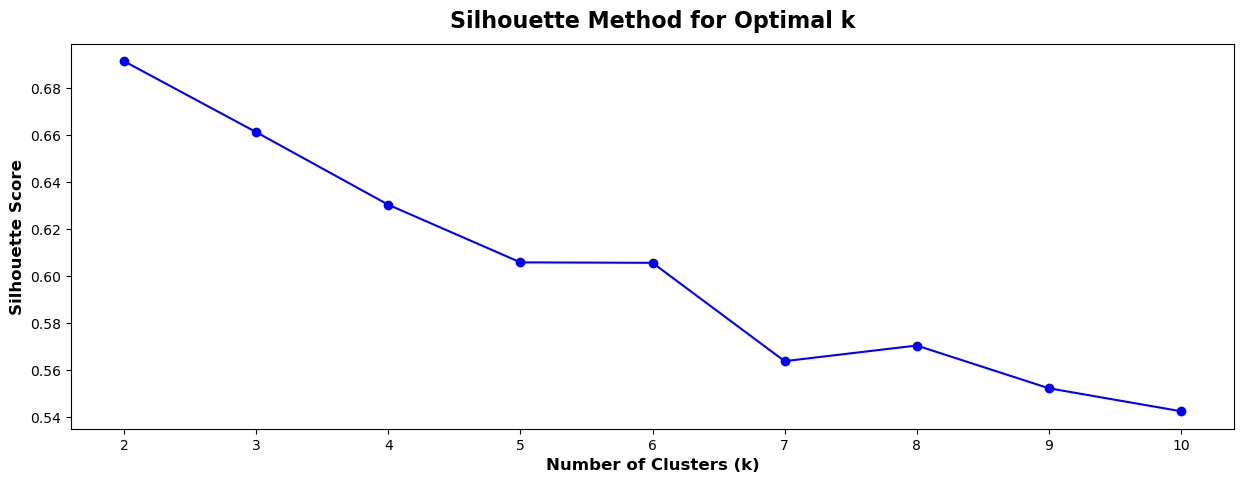

Optimal number of clusters: 2


,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,48.558927,8.436838,209.708539,1417,64.0%
1,49.874529,19.904642,1314.872020,797,36.0%


In [12]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []
K = range(2, 11)  # Start from 2 clusters as silhouette score is not defined for 1 cluster

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm)
    score = silhouette_score(rfm, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(15, 5))
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Method for Optimal k', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Find the optimal number of clusters (highest silhouette score)
optimal_k = K[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")

# Perform K-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
y = kmeans.fit_predict(rfm)

# Add cluster labels to the DataFrame
cluster_data = pd.DataFrame(customer_df)
cluster_data.loc[:,'Cluster'] = y

# Interpret clusters
cluster_analysis = cluster_data.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg('mean')
cluster_analysis['n_customers'] = cluster_data.groupby('Cluster').size()
cluster_analysis['percentage_customers'] = ((cluster_analysis['n_customers']/cluster_analysis['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_analysis)


#### **2.3. Gaussian Mixture Model with BIC**

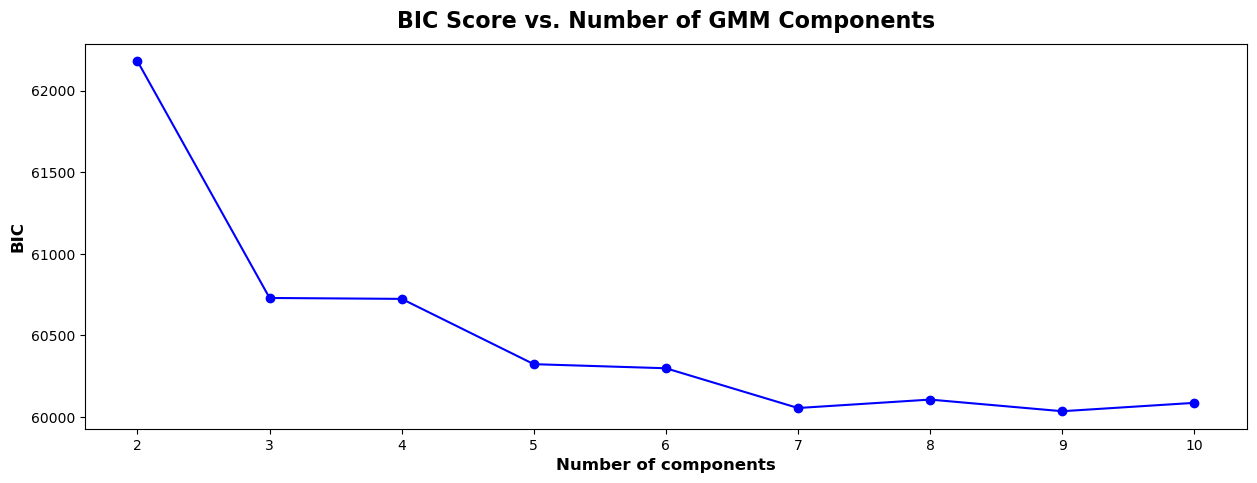

The optimal number of components based on BIC: 9



,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,48.402141,4.570336,45.469419,654,29.5%
1,52.688136,18.098305,1293.586441,295,13.3%
2,48.715100,20.860399,842.202279,351,15.9%
3,55.537313,22.522388,1194.358209,67,3.0%
4,49.514493,17.318841,1915.246377,138,6.2%
5,51.566396,8.165312,179.663957,369,16.7%
6,38.266667,20.516667,1572.933333,60,2.7%
7,43.633333,17.783333,688.083333,60,2.7%
8,44.386364,13.450000,417.586364,220,9.9%


In [13]:
from sklearn.mixture import GaussianMixture

# compute BIC and silhouette scores for different numbers of components
n_components_range = range(2, 11)
bic = []
silhouette_scores = []

for n_components in n_components_range:
    # Fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(rfm)

    # Calculate BIC score
    bic.append(gmm.bic(rfm))

# Plot the BIC scores
print()
plt.figure(figsize=(15, 5))
plt.plot(n_components_range, bic, 'bo-')
plt.xlabel('Number of components', fontsize=12, fontweight='bold')
plt.ylabel('BIC', fontsize=12, fontweight='bold')
plt.title('BIC Score vs. Number of GMM Components', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Find the optimal number of components (lowest BIC)
optimal_components = n_components_range[np.argmin(bic)]
print(f"The optimal number of components based on BIC: {optimal_components}\n")

# Fit GMM with the optimal number of components
gmm = GaussianMixture(n_components=optimal_components, random_state=42)
y = gmm.fit_predict(rfm)

# Add cluster labels to the original dataframe
gmm_clustering_df = pd.DataFrame(customer_df)
gmm_clustering_df.loc[:, 'Cluster'] = y

# Interpret clusters
cluster_analysis = gmm_clustering_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg('mean')
cluster_analysis['n_customers'] = gmm_clustering_df.groupby('Cluster').size()
cluster_analysis['percentage_customers'] = ((cluster_analysis['n_customers']/cluster_analysis['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_analysis)


##### __Clustering Analysis of Customers in the customer personality Dataset__

- **K-means clustering + elbow method optimization**,  customers were divided into 4 distinct clusters.

- **K-means clustering + silhouette score optimization**, the dataset was grouped customers into 2 clusters.

- **Gaussian Mixture Model + Bayesian Information Criterion (BIC)**, the customers were separated into 9 clusters.

To maintain interpretability and provide a clear representation of customer personalities, the **K-means clustering solution optimized with the elbow method** was selected, yielding four meaningful customer segments.

In [14]:
# K-means cluster with elbow method
display(cluster_summary)

,Recency,Frequency,Monetary,n_customers,percentage_customers
Cluster,,,,,
0,49.034972,6.017958,100.494329,1058,47.8%
1,51.509225,20.059041,1767.811808,271,12.2%
2,47.128806,16.264637,575.100703,427,19.3%
3,49.336245,19.805677,1122.580786,458,20.7%


#### **2.4. Interpretation of RFM-based K-means clusters:**

##### __Cluster 0 — Low-value / occasional customers (Largest segment: 47.8%)__
- Recency: 49.03 (moderate–high)
- Frequency: 6.02 (very low)
- Monetary: 100.49 (very low)

__Interpretation__:
These are __infrequent and low-spending__ customers who haven't purchased recently. They contribute the least revenue but form the largest portion of the customer base.

__Business meaning__:

- Weak engagement and low loyalty
- High potential churn risk
- Likely "one-time" or inactive customers

__Strategy__:
Reactivation campaigns, discounts, and targeted promotions to bring them back.

---
##### __Cluster 1 — High-value loyal customers (Premium segment: 12.2%)__
- Recency: 51.51 (moderate)
- Frequency: 20.06 (highest)
- Monetary: 1767.81 (highest by far)

__Interpretation__:
They purchase **frequently and spend significantly** more than others, making them the most **profitable segment**.

__Business meaning__:

- Core revenue drivers
- Likely repeat buyers across channels

__Strategy__:
Retention focus: VIP programs, personalized offers, early access.

---
##### __Cluster 2 — Medium engagement, low spend customers (19.3%)__
- Recency: 47.13 (best / most recent among clusters)
- Frequency: 16.26 (moderate-high)
- Monetary: 575.10 (moderate-low)

__Interpretation__:
These customers are **active and relatively recent buyers**, but their spending is moderate. They engage fairly often but in **low-value purchases**.

**Business meaning:**

- Good engagement but low basket value
- Potential to upgrade into higher-value customers
- Responsive to marketing

__Strategy__:
Upselling and cross-selling to increase basket size.

---

##### __Cluster 3 — High-frequency, medium-value customers (20.7%)__
- Recency: 49.34 (moderate)
- Frequency: 19.81 (high)
- Monetary: 1122.58 (high)

__Interpretation__:
These are **frequent shoppers with solid spending** levels, but not as valuable as Cluster 1.

__Business meaning__:

- Strong repeat behavior
- Medium-to-high revenue contribution
- Close to premium segment

__Strategy__:
Retention + upselling to convert them into top-tier customers.

---

##### **Overall insight & Name Each Segment**
- __Cluster 0__ = __At-Risk Low-Value Customers__ (inactive / low-value mass customers) 
- __Cluster 2__ = __Potential Growth Customers__ (active but low-spending customers (growth opportunity)) 
- __Cluster 3__ = __Loyal Regular Customers__ (loyal frequent buyers (strong mid-tier))
- __Cluster 1__ = __Champions / VIP Customers__ (VIP/high-value customers (key revenue drivers)) 



#### **2.5. Cluster Recognition**

**2.5.1. Cluster-wise RFM distribution**

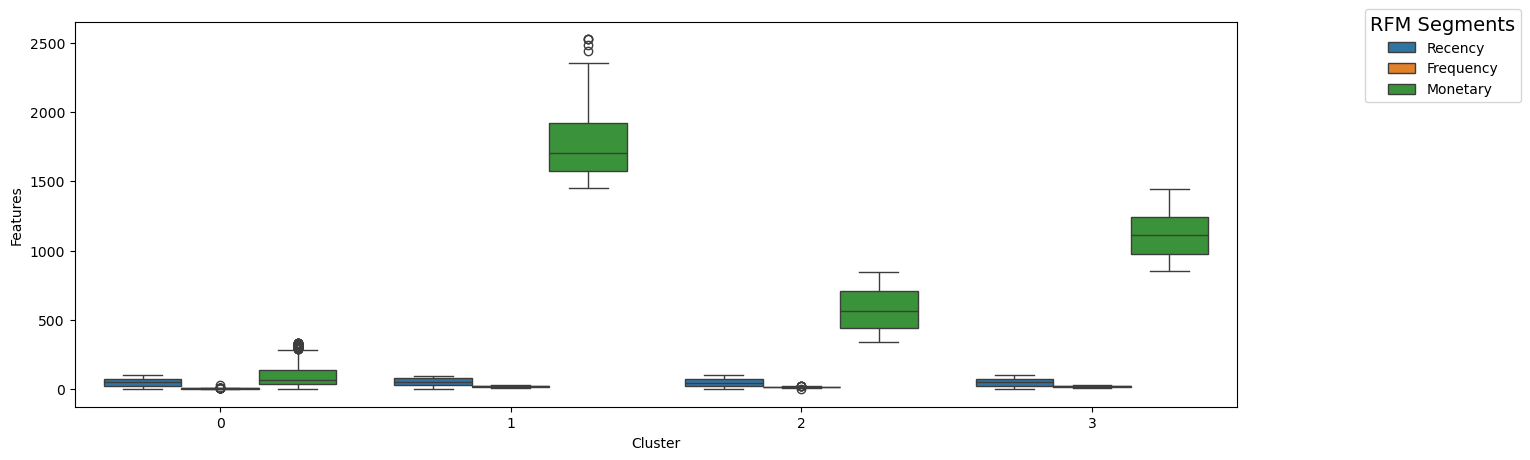

In [15]:
rfm_df = pd.melt(cluster_df, id_vars='Cluster', value_vars=['Recency', 'Frequency', 'Monetary'], value_name='Features')

# visualization
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=rfm_df, x='Cluster', y='Features', hue='variable')
plt.legend(title='RFM Segments', title_fontsize=14, bbox_to_anchor=(1.25, 1.05), loc='upper right', fancybox=True)
plt.show()

**2.5.2. Cluster by Income & Monetary**

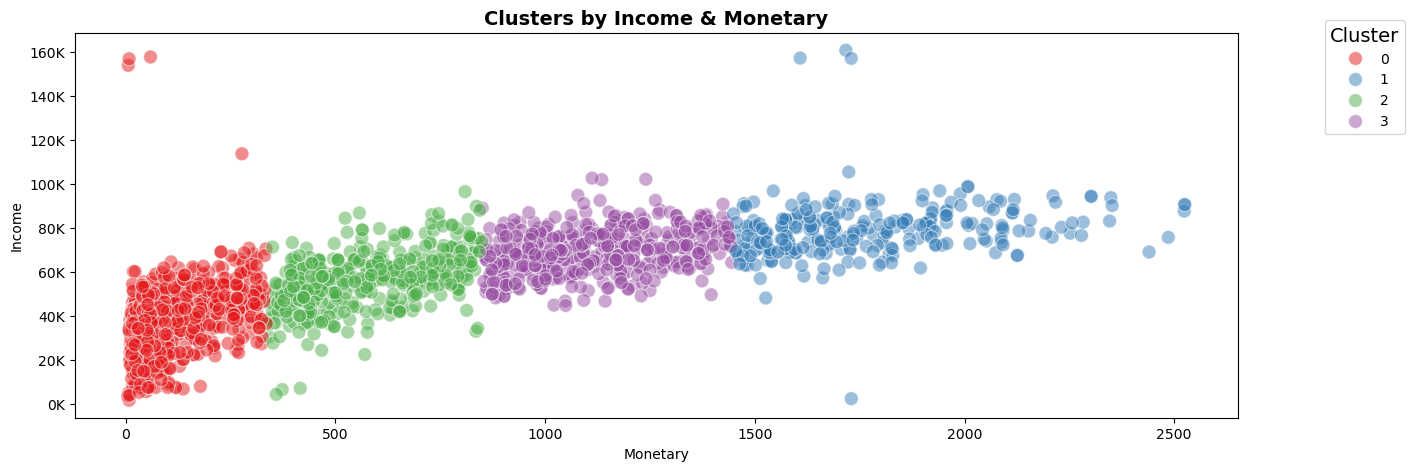

In [16]:
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
fig, ax = plt.subplots(figsize=(15, 5))

sns.scatterplot(
    data=cluster_df,
    x='Monetary',
    y='Income',
    hue='Cluster',              
    palette='Set1',      
    alpha=0.5,                   
    s=100                        
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_title("Clusters by Income & Monetary", fontsize=14, fontweight='bold')
ax.legend(title='Cluster', title_fontsize=14, bbox_to_anchor=(1.15, 1.05), loc='upper right', fancybox=True)

plt.show()



## **3. Quantile Analysis**

**3.1. RFM quantiles**

In [17]:
rfm_data = customer_df[['ID', 'Recency']].copy()
rfm_data = rfm_data.assign(
    Monetary=(
        customer_df['MntFishProducts']
        + customer_df['MntGoldProds']
        + customer_df['MntFruits']
        + customer_df['MntMeatProducts']
        + customer_df['MntSweetProducts']
        + customer_df['MntWines']
    )
)

rfm_data = rfm_data.assign(
    Frequency=customer_df[
        ['NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases']
    ].sum(axis=1)
)
# compute average spending per transaction
rfm_data = rfm_data.assign(
    Monetary=rfm_data['Monetary']/rfm_data['Frequency']
)

rfm_data.head()

,ID,Recency,Monetary,Frequency
0,5524,58,73.500000,22
1,2174,38,6.750000,4
2,4141,26,38.800000,20
3,6182,26,8.833333,6
4,5324,94,30.142857,14


RFM analysis is a popular way to study customer behavior. To do this, compute quantiles for the RFM features and divide customers into five quantiles.

- Recency: 1(High) and 5(Low)
- Frequency and Monetary: 1(Low) and 5(High)
- Scaling customers from 1–5 creates 125 possible RFM scores (5x5x5), ranging from (111 to 555). Since it's not practical to analyze all 125 groups separately, marketers usually simplify by focusing only on the Recency and Frequency scores.

In [18]:

# 1. Compute quantiles for each RFM feature
quantiles = rfm_data[['Recency','Frequency','Monetary']].quantile([0.2,0.4,0.6,0.8]).to_dict()

# 2. Define scoring functions
# Benchmark to give score for recency indicator

def r_score(x, q=quantiles):
    if x <= q['Recency'][0.2]:
        return 5
    elif x <= q['Recency'][0.4]:
        return 4
    elif x <= q['Recency'][0.6]:
        return 3
    elif x <= q['Recency'][0.8]:
        return 2
    else:
        return 1

# Benchmark to give score for frequency & monetary indicator

def fm_score(x, col, q=quantiles):
    if x <= q[col][0.2]:
        return 1
    elif x <= q[col][0.4]:
        return 2
    elif x <= q[col][0.6]:
        return 3
    elif x <= q[col][0.8]:
        return 4
    else:
        return 5

# 3. Apply scoring
rfm_data['R'] = rfm_data['Recency'].apply(lambda x: r_score(x))
rfm_data['F'] = rfm_data['Frequency'].apply(lambda x: fm_score(x, col='Frequency'))
rfm_data['M'] = rfm_data['Monetary'].apply(lambda x: fm_score(x, col='Monetary'))

# 4. Combine into RFM score
rfm_data['RFM_Score'] = rfm_data['R'].map(str) + rfm_data['F'].map(str) + rfm_data['M'].map(str)
display(rfm_data.head())

# Now you have quantile-based RFM scores for segmentation


,ID,Recency,Monetary,Frequency,R,F,M,RFM_Score
0,5524,58,73.500000,22,3,5,5,355
1,2174,38,6.750000,4,4,1,1,411
2,4141,26,38.800000,20,4,4,4,444
3,6182,26,8.833333,6,4,2,1,421
4,5324,94,30.142857,14,1,3,3,133


**3.2. RFM Quantiles Segmentation**

We add a "Segments" column to `rfm_data` by applying a `classifier` function. This function evaluates each customer's RFM quartile scores against predefined rules and assigns them to behavior groups such as Champions, Loyal Customers, or Potential Loyalists. In effect, it translates raw RFM patterns into clear, actionable customer segments.

In [19]:
# creating five quartiles based on recency and frequency metrics, excluding monetary
RF_segmentation_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At risk',
    r'[1-2]5': 'Can\'t loose',
    r'3[1-2]': 'About to sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm_data['Segment'] = rfm_data['R'].map(str) + rfm_data['F'].map(str)
rfm_data['Segment'] = rfm_data['Segment'].replace(RF_segmentation_map, regex=True)
rfm_data.head()


,ID,Recency,Monetary,Frequency,R,F,M,RFM_Score,Segment
0,5524,58,73.500000,22,3,5,5,355,Loyal Customers
1,2174,38,6.750000,4,4,1,1,411,Promising
2,4141,26,38.800000,20,4,4,4,444,Loyal Customers
3,6182,26,8.833333,6,4,2,1,421,Potential Loyalists
4,5324,94,30.142857,14,1,3,3,133,At risk


- **Champions**: Buy often, spend the most, and purchased recently.

- **Loyal Customers**: Regular buyers who respond well to promotions.

- **Potential Loyalists**: Newer customers with average buying frequency.

- **New Customers**: Just purchased, but not very often.

- **Promising**: Shopped recently but spent little.

- **Customers Needing Attention**: Good spenders overall, but haven’t bought very recently.

- **About to Sleep**: Low recency and frequency; risk of losing them.

- **At Risk**: Used to buy often, but last purchase was long ago.

- **Can't Lose Them**: Once frequent buyers, now inactive for a long time.

- **Hibernating**: Few orders and last purchase was long ago; likely lost.

In [20]:
rfm_data.head()

,ID,Recency,Monetary,Frequency,R,F,M,RFM_Score,Segment
0,5524,58,73.500000,22,3,5,5,355,Loyal Customers
1,2174,38,6.750000,4,4,1,1,411,Promising
2,4141,26,38.800000,20,4,4,4,444,Loyal Customers
3,6182,26,8.833333,6,4,2,1,421,Potential Loyalists
4,5324,94,30.142857,14,1,3,3,133,At risk


After segmenting customers, we can count how many belong to each group, design tailored strategies for them, and concentrate on the segments that matter most.

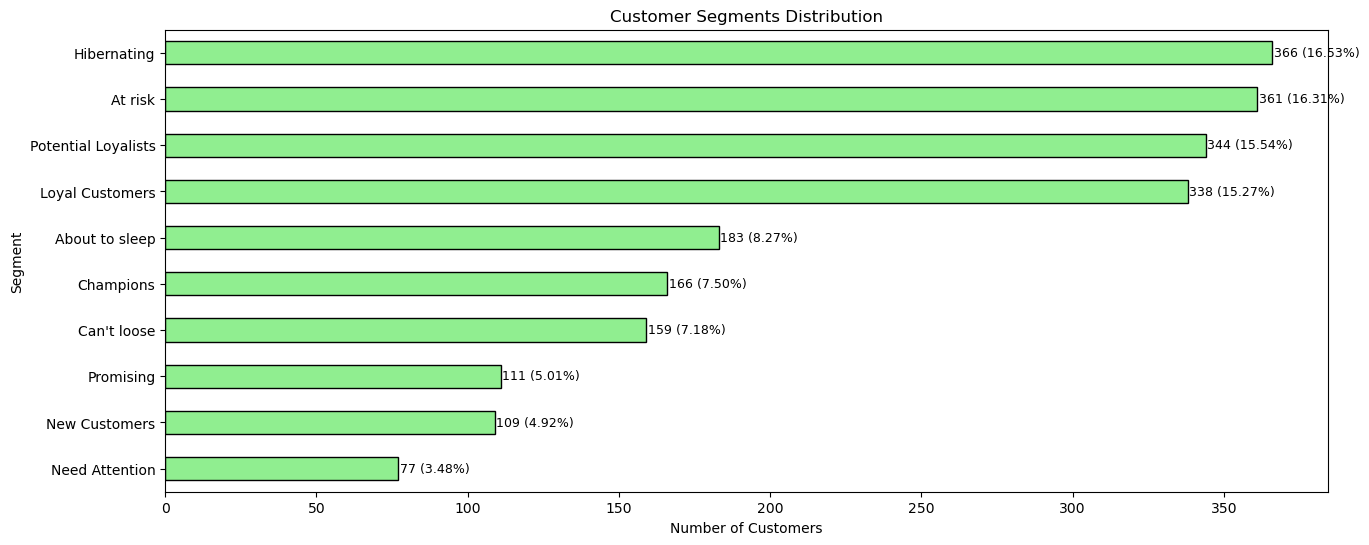

In [21]:
segment_counts = rfm_data['Segment'].value_counts().sort_values(ascending=True)

# Visualize this using bar plot
plt.figure(figsize=(15, 6))
rfm_data['Segment'].value_counts().sort_values(ascending=True).plot(kind='barh', color='lightgreen', ec='k')

plt.title("Customer Segments Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

# Annotate each bar with its value
for i, (segment, value) in enumerate(zip(segment_counts.index, segment_counts.values)):
    plt.text(value+0.5, i, f'{value} ({value/segment_counts.values.sum()*100:.2f}%)', va='center', fontsize=9)  # +5 shifts text slightly right

plt.show()

In [24]:
# Concatenate rfm_data and processed_df to form the complete dataset.

full_df = pd.merge(processed_df.drop(columns=['Recency', 'Monetary', 'Frequency']), rfm_data, on='ID',how='left')
full_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Tenure,Recency,Monetary,Frequency,R,F,M,RFM_Score,Segment
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,28,58,73.500000,22,3,5,5,355,Loyal Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,9,38,6.750000,4,4,1,1,411,Promising
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,16,26,38.800000,20,4,4,4,444,Loyal Customers
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,10,26,8.833333,6,4,2,1,421,Potential Loyalists
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,11,94,30.142857,14,1,3,3,133,At risk


**3.3. Segmentation Recognition**

__3.3.1. Cluster by Income & Monetary__

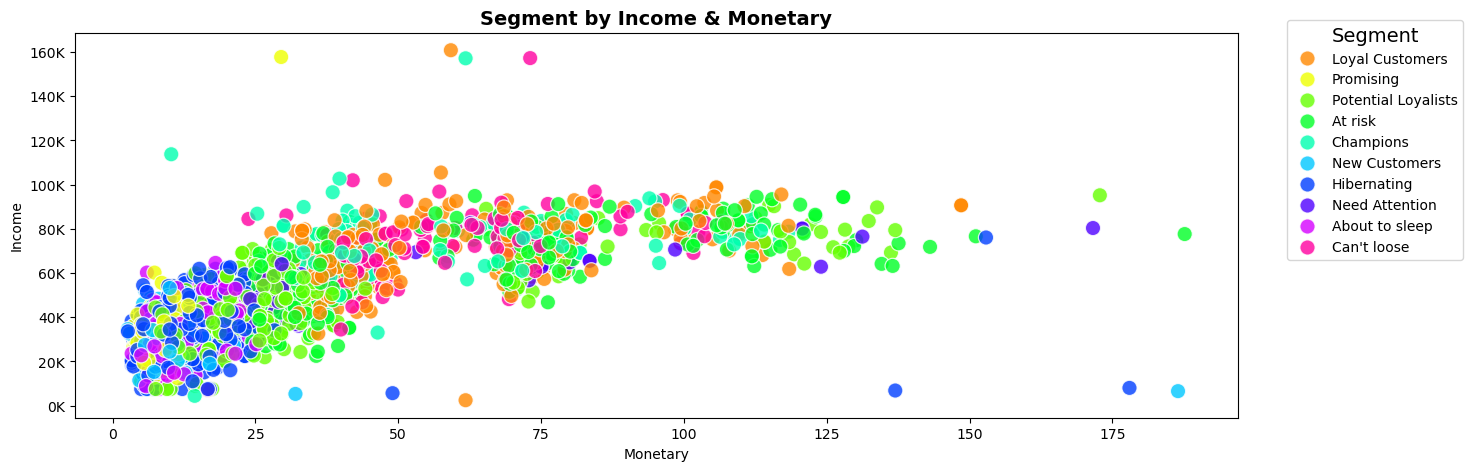

In [40]:
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
fig, ax = plt.subplots(figsize=(15, 5))

sns.scatterplot(
    data=full_df,
    x='Monetary',
    y='Income',
    hue='Segment',              
    palette=sns.color_palette(palette='hsv', n_colors=full_df['Segment'].nunique()),      
    alpha=0.8,                   
    s=120                        
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_title("Segment by Income & Monetary", fontsize=14, fontweight='bold')
ax.legend(title='Segment', title_fontsize=14, bbox_to_anchor=(1.2, 1.05), loc='upper right', fancybox=True)

plt.show()

We've created segments and analyzed their purchasing habits; now let’s identify the customers within each group.


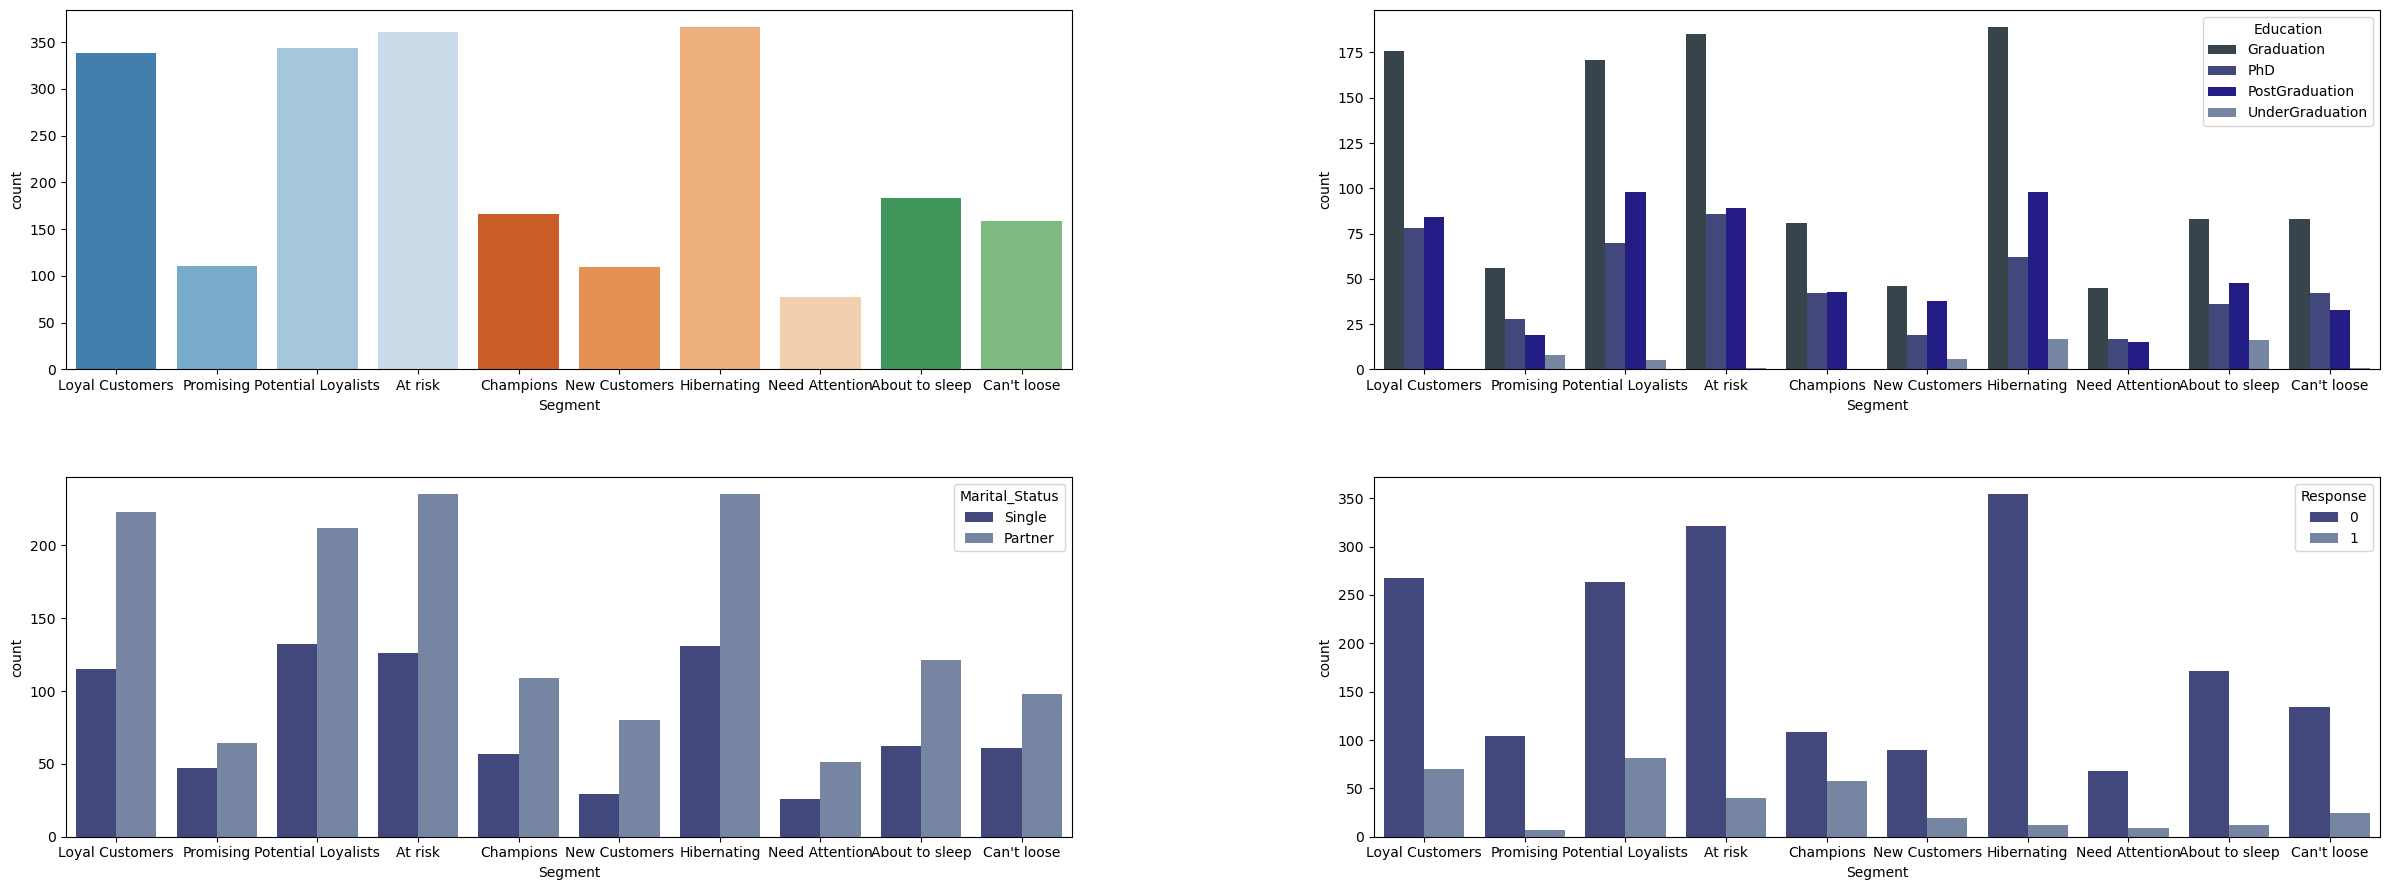

In [51]:

# Create a 2x2 grid layout
fig, axes = plt.subplots(2, 2, figsize=(24, 9))

# Plot 1: Segment counts
sns.countplot(x="Segment", data=full_df, palette="tab20c", ax=axes[0,0])

# Plot 2: Segment vs Education
sns.countplot(x="Segment", hue="Education", data=full_df,
              palette=['#334550','#394184',"#140A97", '#6D83AA'], ax=axes[0,1])

# Plot 3: Segment vs Marital_Status
sns.countplot(x="Segment", hue="Marital_Status", data=full_df,
              palette=['#394184','#6D83AA'], ax=axes[1,0])

# Plot 4: Segment vs Response
sns.countplot(x="Segment", hue="Response", data=full_df,
              palette=['#394184','#6D83AA'], ax=axes[1,1])

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


### **Future Work:** 

The saved segmentation file will be used in the next stage to implement a probabilistic approach for computing Customer Lifetime Value (CLTV). The BG/NBD model will estimate how long customers remain active and how many future purchases they are likely to make, while the Gamma-Gamma model will predict the average profit expected from each customer. Together, these models provide a comprehensive view of customer profitability and long-term business value.